In [8]:
import pandas as pd 

import mysql.connector
db_settings = {
    "host": "localhost",
    "user": "root",
    "password": "Mysql@2026",
    "database": "db_7"
}
try:
        


                                
        conn=mysql.connector.connect(**db_settings)

        query=""" 
        Select s.OrderID, s.OrderDate, s.ProductID, s.RegionID, s.Quantity, s.TotalRevenue, p.unitprice, r.regionname,r.country,p.productname,p.category,
        sum(s.totalrevenue) over(partition by p.ProductName  ) AS Total_Rev,
        dense_rank () over (partition by p.ProductName order by s.TotalRevenue desc ) AS Ranking 
        from sales s 
        inner join products p on s.productid=p.productid
        inner join regions r on s.regionid=r.regionid; """



                                        # Load it into a 'DataFrame'
        df=pd.read_sql(query,conn)
        print("Step 3 Complete: Data is now in Python!")
        display(df)
    
except Exception as e:
        print(f"Error: {e}")


    

Step 3 Complete: Data is now in Python!


C:\Users\Supri\AppData\Local\Temp\ipykernel_23128\4103258014.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


,OrderID,OrderDate,ProductID,RegionID,Quantity,TotalRevenue,unitprice,regionname,country,productname,category,Total_Rev,Ranking
0,5011,2025-07-04,107,5,5,42500.0,8500.0,Middle East,UAE,4K Webcam,Electronics,51000.0,1
1,5019,2026-02-14,107,2,1,8500.0,8500.0,Europe,UK,4K Webcam,Electronics,51000.0,2
2,5008,2025-04-12,106,3,10,8000.0,800.0,Asia-Pacific,India,Ergonomic Mouse Pad,Accessories,8000.0,1
3,5016,2025-12-05,101,3,3,225000.0,75000.0,Asia-Pacific,India,Laptop Pro,Electronics,600000.0,1
4,5001,2025-01-15,101,3,2,150000.0,75000.0,Asia-Pacific,India,Laptop Pro,Electronics,600000.0,2
5,5004,2025-02-12,101,2,1,75000.0,75000.0,Europe,UK,Laptop Pro,Electronics,600000.0,3
6,5007,2026-01-15,101,3,1,75000.0,75000.0,Asia-Pacific,India,Laptop Pro,Electronics,600000.0,3
7,5012,2025-08-19,101,6,1,75000.0,75000.0,Southeast Asia,Singapore,Laptop Pro,Electronics,600000.0,3
8,5020,2026-03-01,105,5,4,18000.0,4500.0,Middle East,UAE,Mechanical Keyboard,Accessories,27000.0,1
9,5006,2025-03-10,105,4,2,9000.0,4500.0,South America,Brazil,Mechanical Keyboard,Accessories,27000.0,2


In [9]:
df.drop_duplicates(subset='OrderID', inplace=True)
print ("Fill the null value " ,df.fillna({'country':'Unknown_country','regionname':'Unknown_region','Quantity':'0','unitprice':'0','TotalRevenue':'0'},inplace=True))
print (" show the null value" ,df.isnull().sum())
df['OrderDate']=pd.to_datetime(df['OrderDate'])
df['regionname']=df['regionname'].str.strip().str.title()
df['country']=df['country'].str.strip().str.upper()
df[['Quantity','unitprice','TotalRevenue']].describe()
df['TotalRevenue']=df['Quantity']*df['unitprice']
df['Year']=df['OrderDate'].dt.year
df['month']=df['OrderDate'].dt.month_name()
display(df)
# --Math operation--
Avg_elec_sale= df[df['category']=='Electronics']['TotalRevenue'].mean()
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
Total_revenue_bymonth=df.groupby('month')['TotalRevenue'].sum().reindex(months_order)
units_sold=df.groupby('category')['Quantity'].sum().sort_values()
Total_revenue_by_region=df.groupby('regionname')['TotalRevenue'].sum()

df.to_csv(r"C:\Users\Supri\OneDrive\Documents\Sales_project.csv")





Fill the null value      OrderID   OrderDate  ProductID  RegionID  Quantity  TotalRevenue  \
0      5011  2025-07-04        107         5         5       42500.0   
1      5019  2026-02-14        107         2         1        8500.0   
2      5008  2025-04-12        106         3        10        8000.0   
3      5016  2025-12-05        101         3         3      225000.0   
4      5001  2025-01-15        101         3         2      150000.0   
5      5004  2025-02-12        101         2         1       75000.0   
6      5007  2026-01-15        101         3         1       75000.0   
7      5012  2025-08-19        101         6         1       75000.0   
8      5020  2026-03-01        105         5         4       18000.0   
9      5006  2025-03-10        105         4         2        9000.0   
10     5005  2025-03-01        104         3         3       45000.0   
11     5018  2026-01-10        104         6         2       30000.0   
12     5010  2025-06-15        110         

,OrderID,OrderDate,ProductID,RegionID,Quantity,TotalRevenue,unitprice,regionname,country,productname,category,Total_Rev,Ranking,Year,month
0,5011,2025-07-04,107,5,5,42500.0,8500.0,Middle East,UAE,4K Webcam,Electronics,51000.0,1,2025,July
1,5019,2026-02-14,107,2,1,8500.0,8500.0,Europe,UK,4K Webcam,Electronics,51000.0,2,2026,February
2,5008,2025-04-12,106,3,10,8000.0,800.0,Asia-Pacific,INDIA,Ergonomic Mouse Pad,Accessories,8000.0,1,2025,April
3,5016,2025-12-05,101,3,3,225000.0,75000.0,Asia-Pacific,INDIA,Laptop Pro,Electronics,600000.0,1,2025,December
4,5001,2025-01-15,101,3,2,150000.0,75000.0,Asia-Pacific,INDIA,Laptop Pro,Electronics,600000.0,2,2025,January
5,5004,2025-02-12,101,2,1,75000.0,75000.0,Europe,UK,Laptop Pro,Electronics,600000.0,3,2025,February
6,5007,2026-01-15,101,3,1,75000.0,75000.0,Asia-Pacific,INDIA,Laptop Pro,Electronics,600000.0,3,2026,January
7,5012,2025-08-19,101,6,1,75000.0,75000.0,Southeast Asia,SINGAPORE,Laptop Pro,Electronics,600000.0,3,2025,August
8,5020,2026-03-01,105,5,4,18000.0,4500.0,Middle East,UAE,Mechanical Keyboard,Accessories,27000.0,1,2026,March
9,5006,2025-03-10,105,4,2,9000.0,4500.0,South America,BRAZIL,Mechanical Keyboard,Accessories,27000.0,2,2025,March


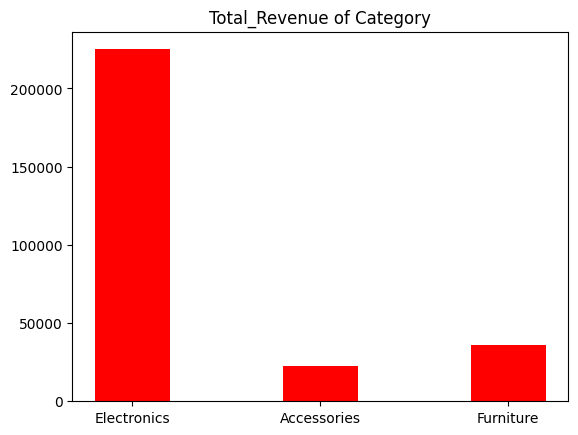

In [10]:
import matplotlib.pyplot as plt
plt.bar(df['category'] , df['TotalRevenue'],width=0.4,color="r")
plt.title("Total_Revenue of Category")
plt.show()

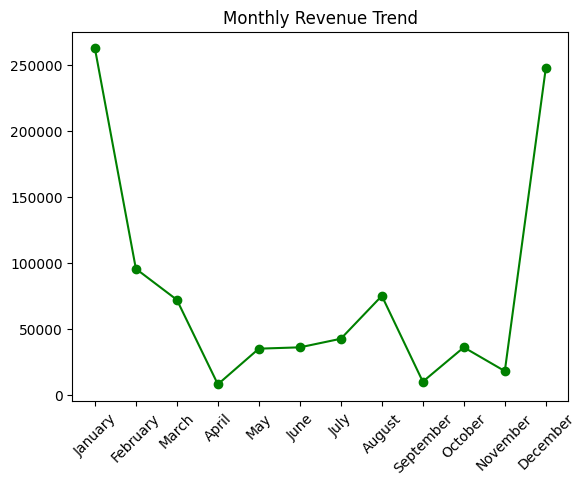

In [11]:
plt.plot(Total_revenue_bymonth, marker='o', color='green')
plt.Figure(figsize=(12,6))
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

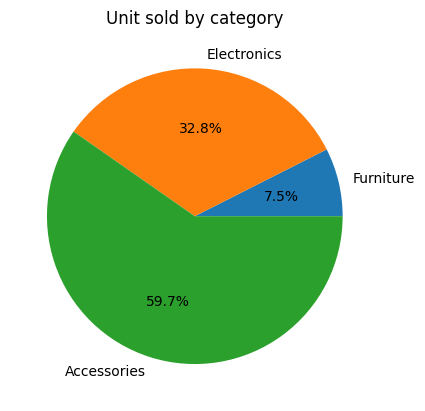

In [12]:
plt.pie(units_sold, labels=units_sold.index ,autopct='%1.1f%%')
plt.title("Unit sold by category")
plt.show()


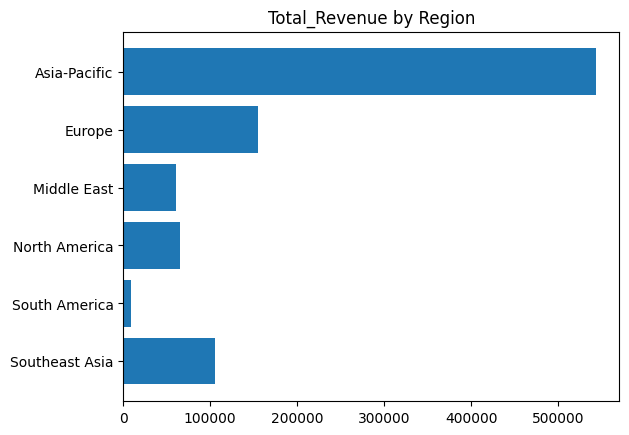

In [13]:
plt.barh(Total_revenue_by_region.index, Total_revenue_by_region)
plt.title("Total_Revenue by Region")
# if you want bottom position to top-most position
plt.gca().invert_yaxis()
plt.show()

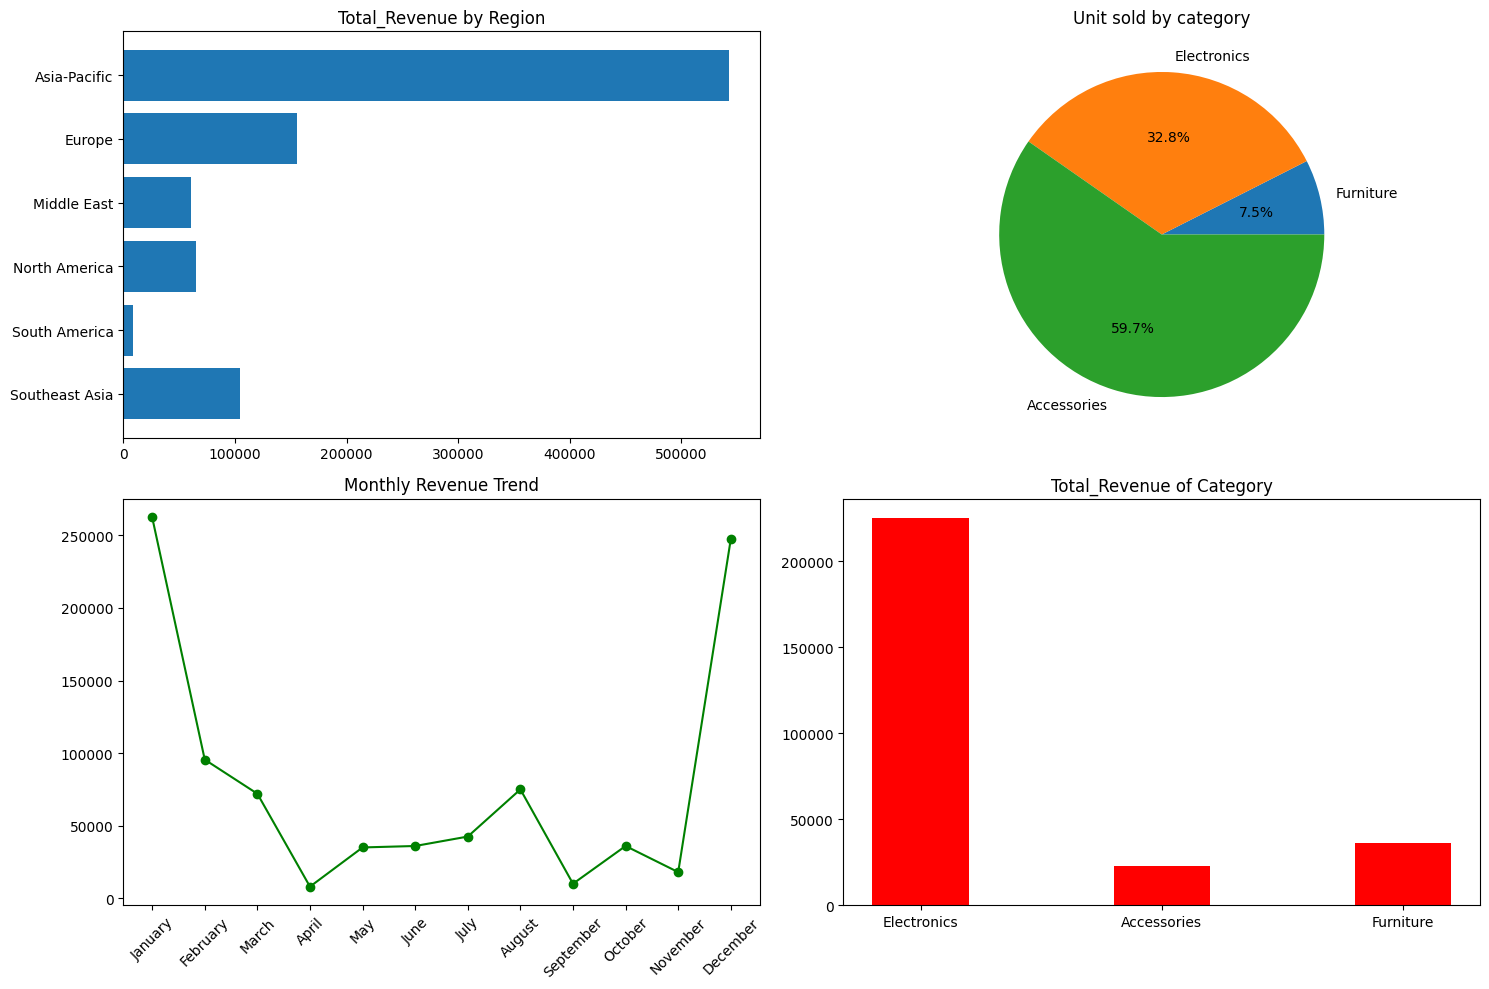

In [14]:
fig,((ax1,ax2),(ax3,ax4))=plt.subplots(2,2,figsize=(15,10))
ax1.barh(Total_revenue_by_region.index, Total_revenue_by_region)
ax1.set_title("Total_Revenue by Region")
# if you want bottom position to top-most position
ax1.invert_yaxis()

ax2.pie(units_sold, labels=units_sold.index ,autopct='%1.1f%%')
ax2.set_title("Unit sold by category")

ax3.plot(Total_revenue_bymonth, marker='o', color='green')
ax3.set_title("Monthly Revenue Trend")
ax3.tick_params(axis='x',rotation=45)

ax4.bar(df['category'] , df['TotalRevenue'],width=0.4,color="r")
ax4.set_title("Total_Revenue of Category")
plt.tight_layout()
plt.savefig('Sales_Performance_Dashboard.png', dpi=300, bbox_inches='tight')
plt.show()




